In [231]:
import os
import numpy as np
import pandas as pd
import torch

from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED
from netam.framework import (
    encode_mut_pos_and_base,
    load_crepe,
    trimmed_shm_model_outputs_of_crepe,
)

from dnsmex.local import localify

from shmex.shm_data import parent_and_child_differ, train_val_dfs_of_nicknames, pcp_df_of_non_shmoof_nickname
from shmex.shm_zoo import standardize_and_optimize_branch_lengths


In [267]:
# functions for comparing mutation rates across different V gene families using count data

def compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']):
    '''
    Calculate mutation rates at a specific site across different V gene families.
    
    This function analyzes mutation rates at a given site across different V families,
    using branch length as a measure of evolutionary time.
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame containing site substitution probabilities with columns:
        - 'site': site position
        - 'sample_id': sample identifier
        - 'family': family identifier
        - 'pcp_index': phylogenetic branch identifier
        - 'branch_length': evolutionary distance (substitutions per site)
        - 'germline_amino_acid': original amino acid at germline
        - 'is_germline_aa': boolean indicating if current AA matches germline
        - 'mutation': boolean indicating if site is mutated from germline
        - 'mutations_per_branch': total mutations accumulated on this branch
    
    vfamilies : list
        List of V gene families to compare (default: ['IGHV1', 'IGHV3', 'IGHV4'])
    site : int
        Site position to analyze
        
    Returns:
    --------
    list
        List of dictionaries containing mutation rate data for each V family:
        - 'vfamily': V gene family name
        - 'site': site position
        - 'branch_length': total branch length
        - 'mutations_per_branch': total mutations per branch
        - 'mutation_acquired': number of mutations acquired
        - 'rate': mutations per unit branch length
        - 'rate_mutcount': mutations per mutation count
        
    Notes:
    ------
    - Only analyzes branches where the site has germline amino acid identity
    - Handles cases with zero branch length or mutation count
    - Calculates both branch-length normalized and mutation-count normalized rates
    '''

    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site) & (site_sub_probs_df_germline.v_family.isin(vfamilies))].copy()
    
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]

    vfamily_results = []
    vfamily_results_per_aa = []
    for vfamily in vfamilies:
        # filter for the current V family and only branches that have the germline amino acid at site
        vfamily_df = cur_df[(cur_df['v_family'] == vfamily) & (cur_df.is_germline_aa == True)].copy()
        if vfamily_df.empty:
            print(f"No data for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates for the current V family
        length = vfamily_df['branch_length'].sum()
        length_mutcount = vfamily_df['mutations_per_branch'].sum()

        mutation_acquired = len(vfamily_df[(vfamily_df['mutation'] == True)])

        if length == 0:
            print(f"Zero branch length or mutation count for V family {vfamily} at site {site}")
            continue
        if length_mutcount == 0:
            print(f"Zero mutation count for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates
        rate = mutation_acquired / length
        rate_mutcount = mutation_acquired / length_mutcount
        vfamily_results.append({
            'v_family': vfamily,
            'site': site,
            'branch_length': length,
            'mutation_acquired': mutation_acquired,
            'rate': rate,
            'rate_mutcount': rate_mutcount
        })


        # calculate aa specific rates
        for amino_acid in vfamily_df['germline_amino_acid'].unique():
            aa_df = vfamily_df[vfamily_df['parent_aa'] == amino_acid]
            aa_length = aa_df['branch_length'].sum()
            aa_length_mutcount = aa_df['mutations_per_branch'].sum()

            if aa_df.empty:
                continue

            for target_amino_acid in AA_STR_SORTED:
                if amino_acid != target_amino_acid:
                    aa_mutation_acquired = len(aa_df[(aa_df['mutation'] == True) & (aa_df['child_aa'] == target_amino_acid)])
                    
                    # Calculate mutation rates for the specific amino acid
                    rate_aa = aa_mutation_acquired / aa_length
                    rate_aa_mutcount = aa_mutation_acquired / aa_length_mutcount

                    vfamily_results_per_aa.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_aa': amino_acid,
                        'child_aa': target_amino_acid,
                        'branch_length': aa_length,
                        'mutation_acquired': aa_mutation_acquired,
                        'rate': rate_aa,
                        'rate_mutcount': rate_aa_mutcount
                    })

    # # Calculate totals from actual data
    # total_counts = len(cur_df[['family', 'sample_id', 'pcp_index']].drop_duplicates())
    # total_branch_length = cur_df['branch_length'].sum()
    # total_mutations_acquired = len(cur_df[(cur_df['mutation'] == True)])
    
    
    return vfamily_results, vfamily_results_per_aa


def compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline, output_path):
    """
    Calculate mutation rates for all sites across different V gene families.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with site substitution probabilities and germline info
        output_path (str): Base output path to save the results CSV files (without extension)
        
    Returns:
        tuple: (results_df, results_per_aa_df) - DataFrames with results for overall and per-AA analysis
    """
    import pandas as pd
    import os
    
    # Run for all sites
    all_results = []
    all_results_per_aa = []
    site_list = site_sub_probs_df_germline.site.unique().tolist()
    
    print(f"Processing {len(site_list)} sites...")
    
    for i, site in enumerate(site_list):
        if i % 10 == 0:  # Progress indicator
            print(f"Processing site {i+1}/{len(site_list)}: site {site}")
            
        vfamily_results, vfamily_results_per_aa = compare_mutation_rates_on_different_vfamilies(
            site_sub_probs_df_germline, site
        )
        
        # Extend the lists with results from this site
        all_results.extend(vfamily_results)
        all_results_per_aa.extend(vfamily_results_per_aa)

    # Convert to DataFrames
    print("Converting results to DataFrames...")
    results_df = pd.DataFrame(all_results)
    results_per_aa_df = pd.DataFrame(all_results_per_aa)
    
    # Generate output file paths
    base_path = output_path.replace('.csv', '')  # Remove .csv if present
    overall_output_path = f"{base_path}_overall_mutation_rates.csv"
    per_aa_output_path = f"{base_path}_per_aa_mutation_rates.csv"
    
    # Save overall results
    if not results_df.empty:
        print(f'Saving overall results to {overall_output_path}')
        results_df.to_csv(overall_output_path, index=False)
        print(f"Overall results: {len(results_df)} rows saved")
    else:
        print("Warning: No overall results to save")
    
    # Save per-amino acid results  
    if not results_per_aa_df.empty:
        print(f'Saving per-amino acid results to {per_aa_output_path}')
        results_per_aa_df.to_csv(per_aa_output_path, index=False)
        print(f"Per-AA results: {len(results_per_aa_df)} rows saved")
    else:
        print("Warning: No per-amino acid results to save")
    
    return results_df, results_per_aa_df


In [268]:
### prepare shm out of frame data
### adapted from thrifty-experiments-1

data_nickname = "tangshm"
dest_dir = "_ignore/neutral_counts_from_non_productive"
os.makedirs(dest_dir, exist_ok=True)

def ragged_np_pcp_encoding(parents, children, site_count=None):
    """
    Encode the mutation indicators, base indices, and masks of a list of
    parent-child pairs.
    """
    mutation_indicator_list = []
    mask_list = []
    for parent, child in zip(parents, children):
        mutation_indicators, _ = encode_mut_pos_and_base(parent, child)
        mutation_indicator_list.append(mutation_indicators.numpy()[:site_count])
        mask_list.append(nt_mask_tensor_of(child).numpy()[:site_count])
    return mutation_indicator_list, mask_list


def detailed_site_df_for(pcp_df):
    """Create a DataFrame with every site, mutation status, branch length, v_gene, and sequence details"""
    mut_indicators, masks = ragged_np_pcp_encoding(
        pcp_df["parent"], pcp_df["child"]
    )
    val_bls = pcp_df["branch_length"].values
    
    detailed_rows = []
    
    for seq_idx, (mask, branch_length, mut_indicator, v_gene, parent_seq, child_seq) in enumerate(
        zip(masks, val_bls, mut_indicators, pcp_df["v_gene"], pcp_df["parent"], pcp_df["child"])
    ):
        
        # For each site in this sequence
        for site_idx in range(len(parent_seq)):
            if mask[site_idx]:  # Only include valid sites
                # Get nucleotides
                parent_nt = parent_seq[site_idx] if site_idx < len(parent_seq) else 'N'
                child_nt = child_seq[site_idx] if site_idx < len(child_seq) else 'N'
                
                # Get codon information (which codon this site belongs to)
                codon_idx = (site_idx // 3)
                codon_position = site_idx % 3  # Position within codon (0, 1, or 2)
                
                # Extract parent and child codons
                codon_start = codon_idx * 3
                codon_end = codon_start + 3
                
                parent_codon = parent_seq[codon_start:codon_end] if codon_end <= len(parent_seq) else 'NNN'
                child_codon = child_seq[codon_start:codon_end] if codon_end <= len(child_seq) else 'NNN'
                
                # Translate codons to amino acids
                try:
                    from Bio.Seq import Seq
                    parent_aa = str(Seq(parent_codon).translate()) if len(parent_codon) == 3 else 'X'
                    child_aa = str(Seq(child_codon).translate()) if len(child_codon) == 3 else 'X'
                except:
                    parent_aa = 'X'
                    child_aa = 'X'
                
                detailed_rows.append({
                    'pcp_index': seq_idx,
                    'nt_site': site_idx,
                    'site': codon_idx + 1,
                    'codon_position': codon_position,
                    'mutation': bool(mut_indicator[site_idx]),
                    'branch_length': branch_length,
                    'v_gene': v_gene,
                    'v_family': v_gene.split('-')[0] if '-' in str(v_gene) else v_gene,
                    'parent_nt': parent_nt,
                    'child_nt': child_nt,
                    'parent_codon': parent_codon,
                    'child_codon': child_codon,
                    'parent_aa': parent_aa,
                    'child_aa': child_aa,
                })
    
    return pd.DataFrame(detailed_rows)


def create_detailed_site_data(
    dataset_name,
):
    """
    Create detailed site-level data with mutation probabilities and observed mutations.
    
    Returns:
    - pcp_df: The parent-child pair DataFrame
    - detailed_site_df: DataFrame with every site and its mutation data
    """
    pcp_df = pcp_df_of_non_shmoof_nickname(dataset_name)

    # Create detailed site data for all sequences
    detailed_site_list = []
    
    # All data
    detailed_all = detailed_site_df_for(pcp_df)
    detailed_site_list.append(detailed_all)
    
    # Combine all detailed data
    detailed_site_df = pd.concat(detailed_site_list, ignore_index=True)
    
    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False)['site'].rank(method='dense').astype(int)
    detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank', 'mutation_occurred':'mutation'}), germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}), on=['v_family', 'v_gene', 'rank'], how='left')
    detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['germline_codon']
    detailed_site_df_germline['is_germline_aa'] = detailed_site_df_germline['parent_aa'] == detailed_site_df_germline['germline_amino_acid']

    # count mutations per branch as an alternative to branch length
    detailed_site_df_germline['mutations_per_branch'] = detailed_site_df_germline.groupby('pcp_index')['mutation'].transform('sum')

    return pcp_df, detailed_site_df


# Create the detailed site data
pcp_df_neutral, detailed_site_df_neutral = create_detailed_site_data(
    dataset_name=data_nickname,
)

Loading /home/nharel/data/v1/tang-deepshm-oof_pcp_2024-04-09_MASKED_NI.csv.gz
Loaded 7000 PCPs from tangshm


In [270]:
## load and perpare data for total mutation rates using counts


def load_or_create_datafile(dataset_name='v1rodriguez', remove_leaves=True):
    model_name = "dnsm_1m-v1jaffe+v1tang-joint"

    crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

    try:
        site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
        pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


    except FileNotFoundError:
        if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
            dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


        complete_plotter, plotter_dict = write_sites_oe(
            crepe_prefix=crepe_prefix,
            dataset_name=dataset_name,
            branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
            csv_output_path=f"{test_output_prefix}-sites-oe.csv",
            fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
            min_log_prob=-4,
            replace_title=True,
        )
        complete_plotter = complete_plotter["heavy"]


        pcp_df = complete_plotter.pcp_df.copy()
        site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
        for column_name in ['selection_factor', 'neutral_prob', 'prob']:
            site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


        pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
        site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name', 'child_is_leaf']]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

    site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
    site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
    site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon

    # count mutations per branch as an alternative to branch length
    site_sub_probs_df_germline['mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['mutation'].transform('sum')


    if remove_leaves:
        print("Removing leaf nodes from the analysis")
        site_sub_probs_df_germline = site_sub_probs_df_germline[~site_sub_probs_df_germline['child_is_leaf']]

    return site_sub_probs_df_germline



site_sub_probs_df_germline_total = load_or_create_datafile()
    



Removing leaf nodes from the analysis


In [273]:
## calculate total and neutral mutation rates

compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total,  '_ignore/total_counts_from_productive/total_mutation_rates.csv')
compare_mutation_rates_on_different_backgrounds_for_all_sites(detailed_site_df_neutral,  '_ignore/neutral_counts_from_non_productive/total_mutation_rates.csv')

Processing 144 sites...
Processing site 1/144: site 1.0
Processing site 11/144: site 12.0
Processing site 21/144: site 22.0
No data for V family IGHV1 at site 31.0
No data for V family IGHV3 at site 31.0
Processing site 31/144: site 34.0
No data for V family IGHV1 at site 34.0
No data for V family IGHV3 at site 34.0
Processing site 41/144: site 44.0
Processing site 51/144: site 54.0
No data for V family IGHV1 at site 60.0
No data for V family IGHV4 at site 60.0
No data for V family IGHV1 at site 61.0
No data for V family IGHV4 at site 61.0
No data for V family IGHV4 at site 62.0
Processing site 61/144: site 64.0
Processing site 71/144: site 75.0
Processing site 81/144: site 85.0
Processing site 91/144: site 95.0
Processing site 101/144: site 105.0
No data for V family IGHV1 at site 107.0
No data for V family IGHV4 at site 107.0
No data for V family IGHV1 at site 108.0
No data for V family IGHV3 at site 108.0
No data for V family IGHV4 at site 108.0
No data for V family IGHV1 at site 10

KeyError: 'germline_amino_acid'

In [161]:
pcp_df

,sample_id,family,parent_name,parent,child_name,child,branch_length,depth,distance,v_gene,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,parent_is_naive,child_is_leaf
0,B21,20627,Node1,GAGGTGTCGATGTTGGAGTCTGGGGGAGACTTGGTACCGCCTGGGG...,14468209,GAGGTGTCGATGTTGGAGTCTGGGGGAGACTTGGTACCGCCGGGGG...,0.024790,2,0.119089,IGHV3-23*01,75,96,150,171,288,338,False,True
1,B21,20627,Node1,GAGGTGTCGATGTTGGAGTCTGGGGGAGACTTGGTACCGCCTGGGG...,14442084,GAGGTGGCGATGTTGGAGTCTGGGGGAGACTTGGTACCGCCTGGGG...,0.015583,2,0.109881,IGHV3-23*01,75,96,150,171,288,338,False,True
2,B21,25204,Node1,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,14472984,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,0.002647,2,0.046952,IGHV4-59*01,75,96,150,168,285,343,False,True
3,B21,608,Node1,CAGGTGCTGCTCCAGCAGTGGGGCGCAGGACTGTTGAAGCCTTCGG...,14444430,CAGGTGCTGCTCCAGCAGTGGGGCGCAGGACTGTTGAAGCCTTCGG...,0.005422,2,0.071525,IGHV4-34*01,75,96,150,168,285,307,False,True
4,B21,608,Node1,CAGGTGCTGCTCCAGCAGTGGGGCGCAGGACTGTTGAAGCCTTCGG...,14508422,CAGGTGCTGCTCCAGCAGTGGGGCGCAGGGCTGTTGGAGCCTTCGG...,0.031267,2,0.097370,IGHV4-34*01,75,96,150,168,285,307,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,AG476,1929,Node1,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,12822719,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,0.148723,2,0.148925,IGHV3-30*18,75,96,150,171,288,335,False,True
6996,AG476,731,Node1,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,12831035,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,0.008428,2,0.025549,IGHV3-30*18,75,96,150,171,288,322,False,True
6997,AG476,2288,Node1,GAAGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,12846308,GAGGTGCAGTTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,0.002651,2,0.087117,IGHV3-9*01,75,96,150,171,288,341,False,True
6998,AG476,1701,Node1,CAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGT...,12866725,CAGGTGCAGCTGGTGCAGTCTGGGGCTGAGGTGAAGAAGCCTGGGT...,0.002722,2,0.002723,IGHV1-69*01,75,96,150,171,288,332,False,True


In [162]:
detailed_site_df

,pcp_index,nt_site,site,codon_position,mutation_occurred,branch_length,v_gene,v_family,parent_nt,child_nt,parent_codon,child_codon,parent_aa,child_aa
0,0,0,1,0,False,0.024790,IGHV3-23*01,IGHV3,G,G,GAG,GAG,E,E
1,0,1,1,1,False,0.024790,IGHV3-23*01,IGHV3,A,A,GAG,GAG,E,E
2,0,2,1,2,False,0.024790,IGHV3-23*01,IGHV3,G,G,GAG,GAG,E,E
3,0,3,2,0,False,0.024790,IGHV3-23*01,IGHV3,G,G,GTG,GTG,V,V
4,0,4,2,1,False,0.024790,IGHV3-23*01,IGHV3,T,T,GTG,GTG,V,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2574413,6999,354,119,0,False,0.002793,IGHV1-69*01,IGHV1,C,C,CTC,CTC,L,L
2574414,6999,355,119,1,False,0.002793,IGHV1-69*01,IGHV1,T,T,CTC,CTC,L,L
2574415,6999,356,119,2,False,0.002793,IGHV1-69*01,IGHV1,C,C,CTC,CTC,L,L
2574416,6999,357,120,0,False,0.002793,IGHV1-69*01,IGHV1,A,A,NNN,NNN,X,X


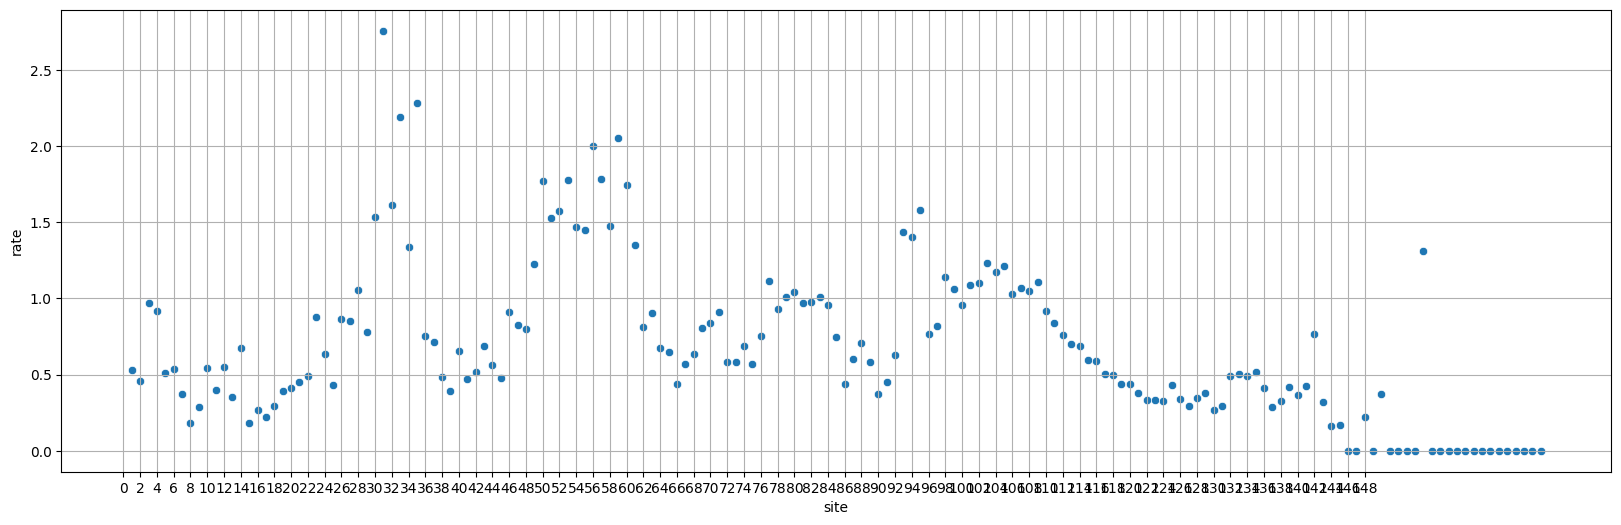

In [163]:
# Basic aggregation - branch length and mutation counts
temp_df = detailed_site_df.groupby('site').agg({
    'branch_length': 'sum',  # Branch length is same for all sites in a sequence
    'mutation_occurred': 'sum',  # Total mutations in this codon
}).reset_index()

temp_df['rate'] = temp_df['mutation_occurred'] / temp_df['branch_length']

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=temp_df, x='site', y='rate', ax=ax)
ax.set_xticks(np.arange(0, 150, 2))
ax.grid()


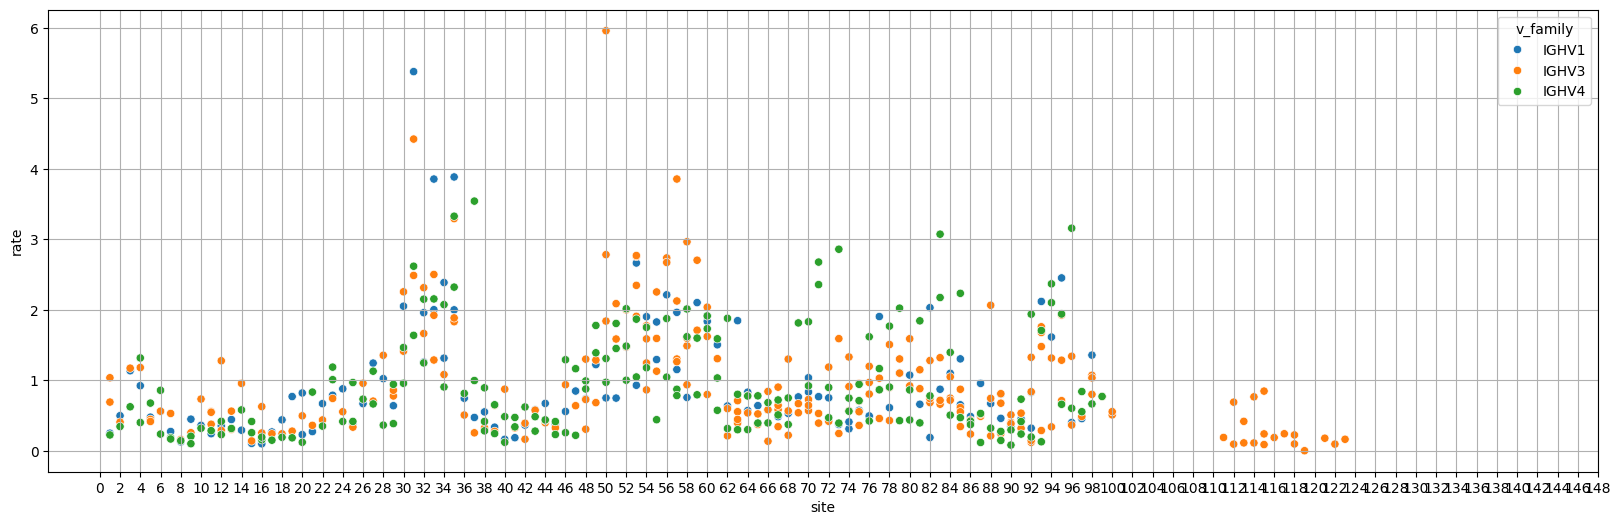

In [164]:
# Aggregation - branch length and mutation counts, grouped by v family and parent codon
temp_df = detailed_site_df.groupby(['v_family', 'site', 'parent_codon']).agg({
    'branch_length': 'sum',  # Branch length is same for all sites in a sequence
    'mutation_occurred': 'sum',  # Total mutations in this codon
}).reset_index()

temp_df['rate'] = temp_df['mutation_occurred'] / temp_df['branch_length']

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=temp_df[(temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])) & (temp_df.branch_length > 20)], x='site', y='rate', hue='v_family', ax=ax)
ax.set_xticks(np.arange(0, 150, 2))
ax.grid()


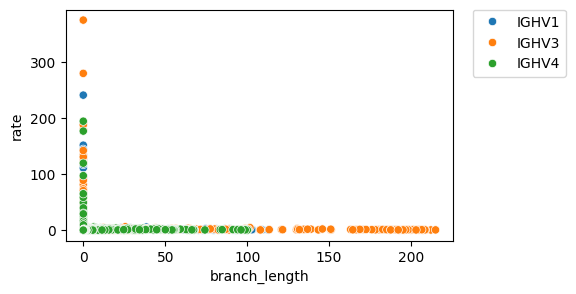

In [165]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.scatterplot(data=temp_df[temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])], x='branch_length', y='rate', hue='v_family')
# move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          borderaxespad=0.)

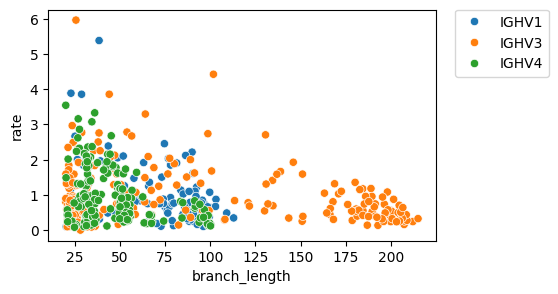

In [166]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.scatterplot(data=temp_df[(temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])) & (temp_df.branch_length > 20)], x='branch_length', y='rate', hue='v_family')
# move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          borderaxespad=0.)

In [167]:
## Add germline codons

In [168]:
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))

In [169]:
germline_codons_df

,site,codon,v_gene,v_family,amino_acid
0,1,CAG,IGHV1-18*01,IGHV1,Q
1,2,GTT,IGHV1-18*01,IGHV1,V
2,3,CAG,IGHV1-18*01,IGHV1,Q
3,4,CTG,IGHV1-18*01,IGHV1,L
4,5,GTG,IGHV1-18*01,IGHV1,V
...,...,...,...,...,...
18852,102,TTT,IGHV8-51-1*05,IGHV8,F
18853,103,AAC,IGHV8-51-1*05,IGHV8,N
18854,104,TGT,IGHV8-51-1*05,IGHV8,C
18855,105,GCA,IGHV8-51-1*05,IGHV8,A


In [170]:
# Detailed analysis showing which specific sites differ
for v_family, family_group in germline_codons_df.groupby('v_family'):
    site_sets_by_gene = family_group.groupby('v_gene')['site'].apply(set)
    
    # Check if all gene sets are identical
    first_gene = site_sets_by_gene.index[0]
    first_set = site_sets_by_gene.iloc[0]
    
    all_same = all(sites == first_set for sites in site_sets_by_gene)
    
    if all_same:
        print(f"✅ {v_family}: All {len(site_sets_by_gene)} genes have identical site numbering")
    else:
        print(f"❌ {v_family}: Site numbering differs between genes:")
        
        # Show all sites across all genes in this family
        all_sites = set.union(*site_sets_by_gene.values)
        
        for v_gene, gene_sites in site_sets_by_gene.items():
            only_in_this_gene = gene_sites - first_set
            missing_from_this_gene = first_set - gene_sites
            
            print(f"  {v_gene}: {len(gene_sites)} sites")
            if only_in_this_gene:
                print(f"    Extra sites: {sorted(only_in_this_gene)}")
            if missing_from_this_gene:
                print(f"    Missing sites: {sorted(missing_from_this_gene)}")

✅ IGHV1: All 41 genes have identical site numbering
✅ IGHV2: All 11 genes have identical site numbering
❌ IGHV3: Site numbering differs between genes:
  IGHV3-11*01: 98 sites
  IGHV3-11*04: 98 sites
  IGHV3-11*05: 98 sites
  IGHV3-11*06: 98 sites
  IGHV3-13*01: 97 sites
    Missing sites: [62]
  IGHV3-13*04: 97 sites
    Missing sites: [62]
  IGHV3-13*05: 97 sites
    Missing sites: [62]
  IGHV3-13*06: 97 sites
    Missing sites: [62]
  IGHV3-15*01: 100 sites
    Extra sites: [60, 61]
  IGHV3-15*07: 100 sites
    Extra sites: [60, 61]
  IGHV3-16*02: 98 sites
  IGHV3-16*03: 98 sites
  IGHV3-16*04: 98 sites
  IGHV3-19*01: 98 sites
  IGHV3-20*01: 98 sites
  IGHV3-20*02: 98 sites
  IGHV3-20*04: 98 sites
  IGHV3-21*01: 98 sites
  IGHV3-21*03: 98 sites
  IGHV3-21*05: 98 sites
  IGHV3-21*06: 98 sites
  IGHV3-21*07: 98 sites
  IGHV3-23*01: 98 sites
  IGHV3-23*03: 98 sites
  IGHV3-23*04: 98 sites
  IGHV3-25*04: 98 sites
  IGHV3-30*01: 98 sites
  IGHV3-30*02: 98 sites
  IGHV3-30*03: 98 sites
  I

In [171]:
detailed_site_df

,pcp_index,nt_site,site,codon_position,mutation_occurred,branch_length,v_gene,v_family,parent_nt,child_nt,parent_codon,child_codon,parent_aa,child_aa
0,0,0,1,0,False,0.024790,IGHV3-23*01,IGHV3,G,G,GAG,GAG,E,E
1,0,1,1,1,False,0.024790,IGHV3-23*01,IGHV3,A,A,GAG,GAG,E,E
2,0,2,1,2,False,0.024790,IGHV3-23*01,IGHV3,G,G,GAG,GAG,E,E
3,0,3,2,0,False,0.024790,IGHV3-23*01,IGHV3,G,G,GTG,GTG,V,V
4,0,4,2,1,False,0.024790,IGHV3-23*01,IGHV3,T,T,GTG,GTG,V,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2574413,6999,354,119,0,False,0.002793,IGHV1-69*01,IGHV1,C,C,CTC,CTC,L,L
2574414,6999,355,119,1,False,0.002793,IGHV1-69*01,IGHV1,T,T,CTC,CTC,L,L
2574415,6999,356,119,2,False,0.002793,IGHV1-69*01,IGHV1,C,C,CTC,CTC,L,L
2574416,6999,357,120,0,False,0.002793,IGHV1-69*01,IGHV1,A,A,NNN,NNN,X,X


In [172]:
germline_codons_df

,site,codon,v_gene,v_family,amino_acid
0,1,CAG,IGHV1-18*01,IGHV1,Q
1,2,GTT,IGHV1-18*01,IGHV1,V
2,3,CAG,IGHV1-18*01,IGHV1,Q
3,4,CTG,IGHV1-18*01,IGHV1,L
4,5,GTG,IGHV1-18*01,IGHV1,V
...,...,...,...,...,...
18852,102,TTT,IGHV8-51-1*05,IGHV8,F
18853,103,AAC,IGHV8-51-1*05,IGHV8,N
18854,104,TGT,IGHV8-51-1*05,IGHV8,C
18855,105,GCA,IGHV8-51-1*05,IGHV8,A


In [173]:
# Using sort=False to preserve original order
germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False)['site'].rank(method='dense').astype(int)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102],
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0'),
  Text(5, 0, '6.0'),
  Text(6, 0, '7.0'),
  Text(7, 0, '8.0'),
  Text(8, 0, '9.0'),
  Text(9, 0, '11.0'),
  Text(10, 0, '12.0'),
  Text(11, 0, '13.0'),
  Text(12, 0, '14.0'),
  Text(13, 0, '15.0'),
  Text(14, 0, '16.0'),
  Text(15, 0, '17.0'),
  Text(16, 0, '18.0'),
  Text(17, 0, '1

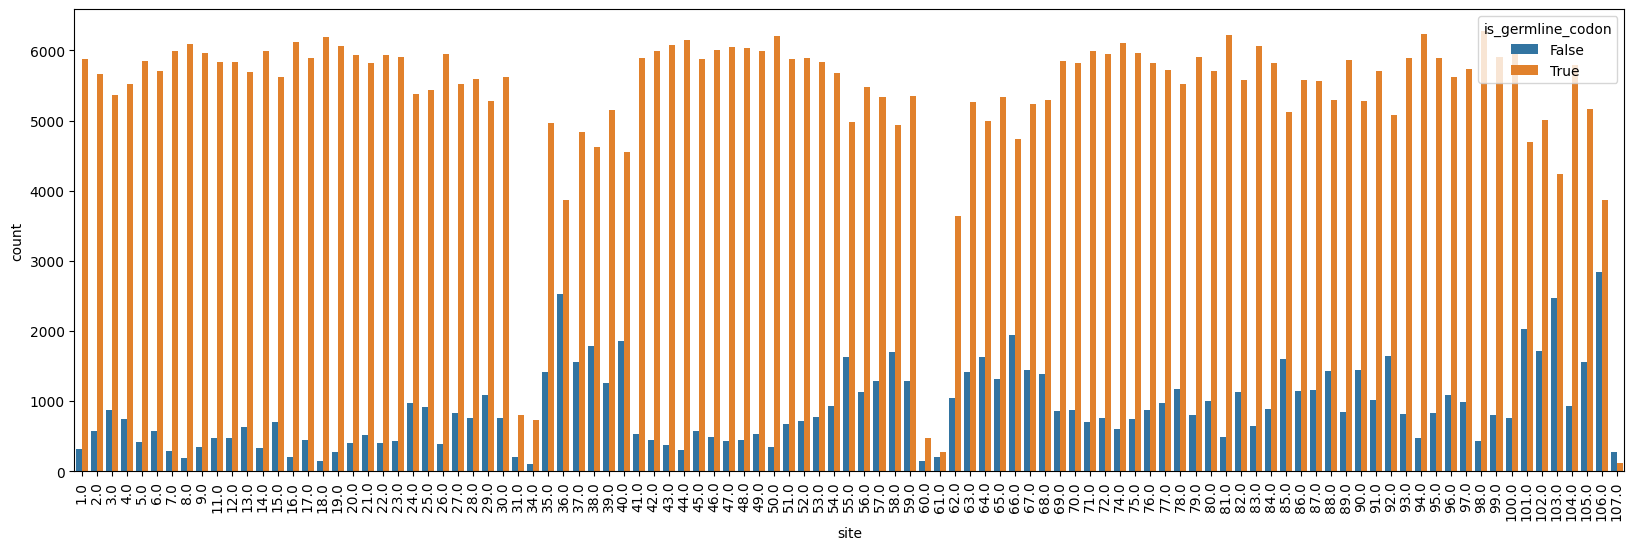

In [174]:
# let's check how much this the germline matches the detailed site data
temp_df = pd.merge(detailed_site_df.rename(columns={'site':'rank'}), germline_codons_df, on=['v_family', 'v_gene', 'rank'], how='left')[['pcp_index', 'site', 'v_gene', 'v_family', 'rank', 'parent_codon', 'parent_aa', 'codon', 'amino_acid']].drop_duplicates()


temp_df['is_germline_codon'] = temp_df['parent_codon'] == temp_df['codon']

fig, ax = plt.subplots(figsize=(20, 6))
sns.countplot(data=temp_df, x='site', hue='is_germline_codon', ax=ax)
# rotate x-axis labels for better readability
plt.xticks(rotation=90)


In [ ]:
## add germline information
germline_codons_df['rank'] = germline_codons_df.groupby('v_gene', sort=False)['site'].rank(method='dense').astype(int)
detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank', 'mutation_occurred':'mutation'}), germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}), on=['v_family', 'v_gene', 'rank'], how='left')
detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['germline_codon']
detailed_site_df_germline['is_germline_aa'] = detailed_site_df_germline['parent_aa'] == detailed_site_df_germline['germline_amino_acid']


# count mutations per branch as an alternative to branch length
detailed_site_df_germline['mutations_per_branch'] = detailed_site_df_germline.groupby('pcp_index')['mutation'].transform('sum')

In [237]:
results_df, results_per_aa_df = compare_mutation_rates_on_different_backgrounds_for_all_sites(detailed_site_df_germline, '_ignore/neutral_counts_from_non_productive/neutral_mutation_rates')

Processing 104 sites...
Processing site 1/104: site 1.0
Processing site 11/104: site 12.0
Processing site 21/104: site 22.0
Processing site 31/104: site 36.0
Processing site 41/104: site 46.0
Processing site 51/104: site 56.0
No data for V family IGHV4 at site 62.0
Processing site 61/104: site 68.0
Processing site 71/104: site 79.0
Processing site 81/104: site 89.0
Processing site 91/104: site 99.0
No data for V family IGHV1 at site nan
No data for V family IGHV3 at site nan
No data for V family IGHV4 at site nan
No data for V family IGHV1 at site 60.0
No data for V family IGHV4 at site 60.0
Processing site 101/104: site 61.0
No data for V family IGHV1 at site 61.0
No data for V family IGHV4 at site 61.0
No data for V family IGHV1 at site 31.0
No data for V family IGHV3 at site 31.0
No data for V family IGHV1 at site 34.0
No data for V family IGHV3 at site 34.0
No data for V family IGHV1 at site 107.0
No data for V family IGHV4 at site 107.0
Converting results to DataFrames...
Saving o

In [242]:
results_df.rename(columns={'vfamily': 'v_family'}, inplace=True)
results_per_aa_df.rename(columns={'vfamily': 'v_family'}, inplace=True)

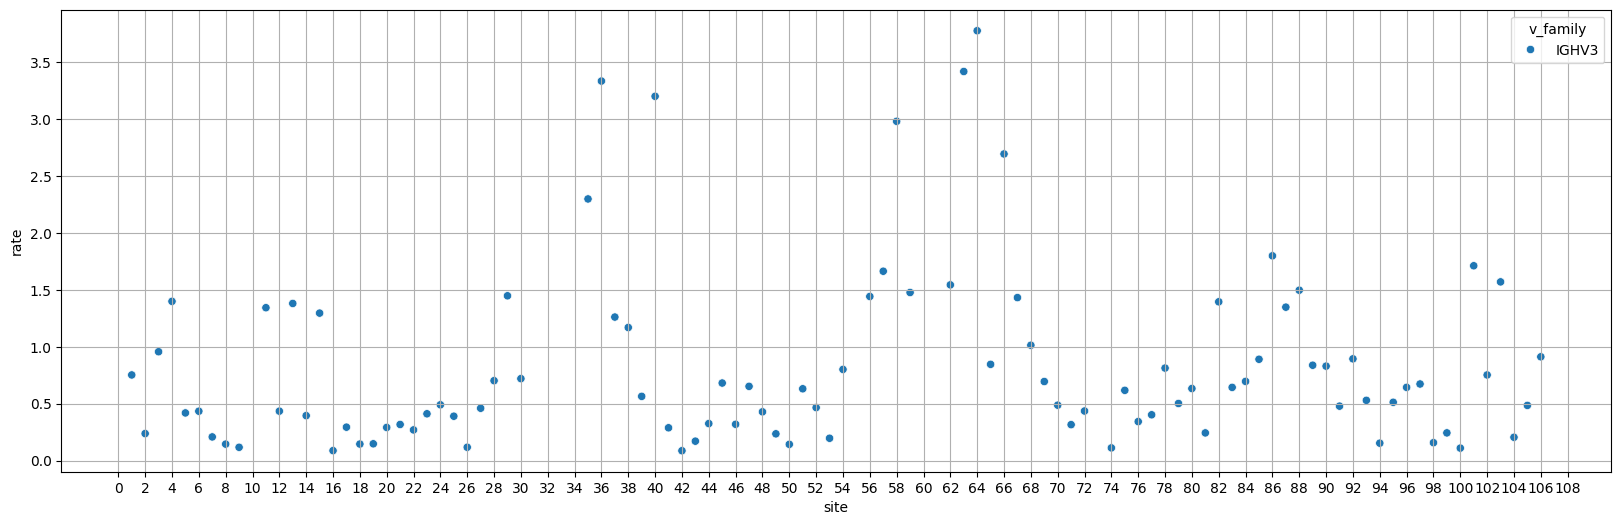

In [194]:
### rate calculation away from germline codons

detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank'}), germline_codons_df, on=['v_family', 'v_gene', 'rank'], how='left')
detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['codon']


# Aggregation - branch length and mutation counts, grouped by v family and parent codon
temp_df = detailed_site_df_germline[(detailed_site_df_germline.is_germline_codon == True) & (detailed_site_df_germline.v_gene == 'IGHV3-23*01')].groupby(['v_family', 'site']).agg({
    'branch_length': 'sum',  # Branch length is same for all sites in a sequence
    'mutation_occurred': 'sum',  # Total mutations in this codon
}).reset_index()

temp_df['rate'] = temp_df['mutation_occurred'] / temp_df['branch_length']

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=temp_df[(temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])) & (temp_df.branch_length > 20)], x='site', y='rate', hue='v_family', ax=ax)
ax.set_xticks(np.arange(0, 110, 2))
ax.grid()


In [195]:
temp_df[(temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])) & (temp_df.branch_length > 10) & (temp_df.site == 38)]

,v_family,site,branch_length,mutation_occurred,rate
32,IGHV3,38.0,32.502356,38,1.169146


In [ ]:
## change branch length calculations to be mutation freq instead

AttributeError: PathCollection.set() got an unexpected keyword argument 'shape'

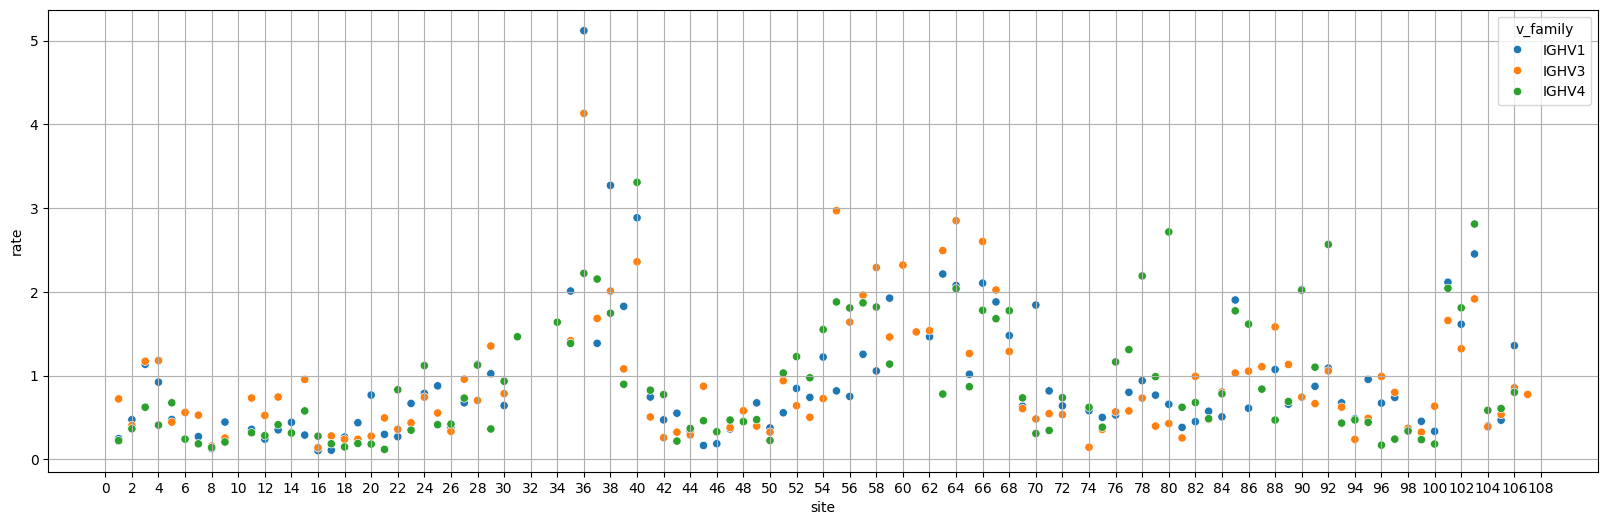

In [ ]:
# compare to total counts

### rate calculation away from germline codons

detailed_site_df_germline = pd.merge(detailed_site_df.rename(columns={'site':'rank'}), germline_codons_df, on=['v_family', 'rank'], how='left')
detailed_site_df_germline['is_germline_codon'] = detailed_site_df_germline['parent_codon'] == detailed_site_df_germline['codon']


# Aggregation - branch length and mutation counts, grouped by v family and parent codon
temp_df = detailed_site_df_germline[(detailed_site_df_germline.is_germline_codon == True)].groupby(['v_family', 'site']).agg({
    'branch_length': 'sum',  # Branch length is same for all sites in a sequence
    'mutation_occurred': 'sum',  # Total mutations in this codon
}).reset_index()

temp_df['rate'] = temp_df['mutation_occurred'] / temp_df['branch_length']

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=temp_df[(temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])) & (temp_df.branch_length > 20)], x='site', y='rate', hue='v_family', ax=ax)
ax.set_xticks(np.arange(0, 110, 2))
ax.grid()





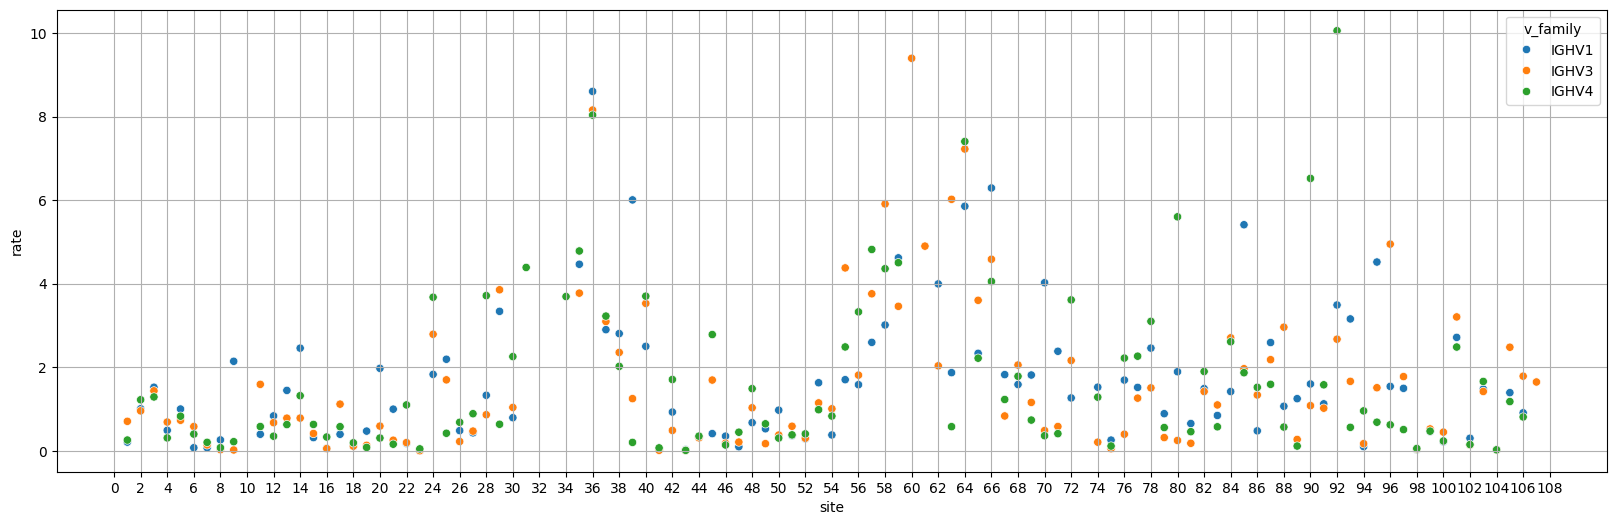

In [247]:
df = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_203456_no_leaves_overall_mutation_rates.csv').rename(columns={'vfamily':'v_family'})

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(data=df[df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])], x='site', y='rate', hue='v_family', ax=ax)
ax.set_xticks(np.arange(0, 110, 2))
ax.grid()

In [207]:
temp_df

,v_family,site,branch_length,mutation_occurred,rate
0,IGHV1,1.0,3280.721533,814,0.248116
1,IGHV1,2.0,1224.559719,581,0.474456
2,IGHV1,3.0,3431.376890,3895,1.135113
3,IGHV1,4.0,2986.064842,2754,0.922284
4,IGHV1,5.0,3605.081525,1718,0.476550
...,...,...,...,...,...
690,IGHV7,102.0,12.452226,24,1.927366
691,IGHV7,103.0,11.953841,30,2.509654
692,IGHV7,104.0,17.036708,0,0.000000
693,IGHV7,105.0,14.144880,5,0.353485


In [208]:
df

,v_family,site,branch_length,mutation_acquired,rate
0,IGHV1,1.0,363.356998,75,0.206409
1,IGHV3,1.0,1509.921907,1063,0.704010
2,IGHV4,1.0,454.022253,116,0.255494
3,IGHV1,2.0,355.285336,357,1.004826
4,IGHV3,2.0,1495.151122,1427,0.954419
...,...,...,...,...,...
293,IGHV4,105.0,436.775724,514,1.176805
294,IGHV1,106.0,316.106914,287,0.907921
295,IGHV3,106.0,1208.934672,2158,1.785043
296,IGHV4,106.0,397.448505,321,0.807652


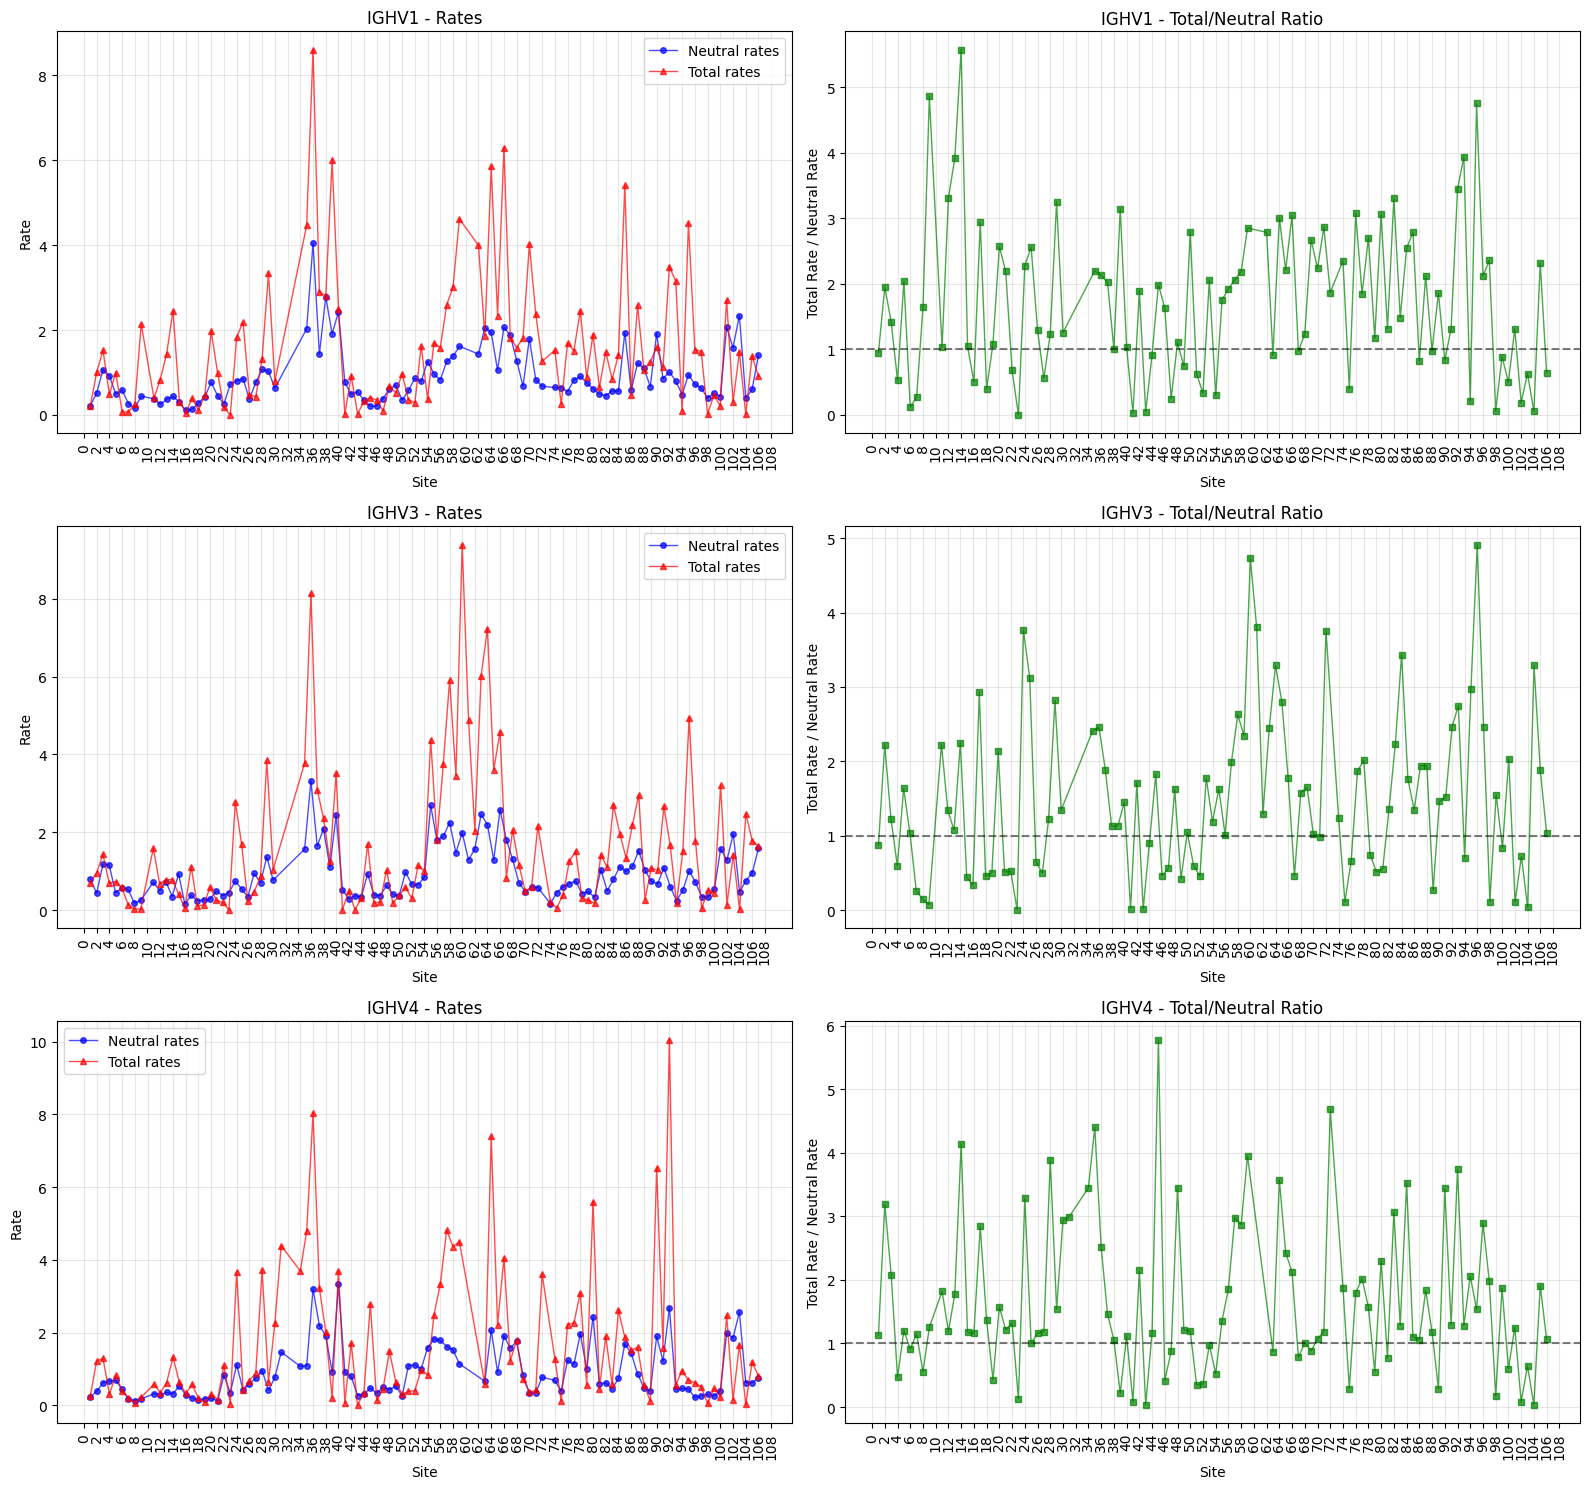

In [248]:
# Version with 3 rows (v_families) and 2 columns (rates, ratio)
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, v_family in enumerate(v_families):
    # Left column - rates
    ax_rates = axes[i, 0]
    
    # Filter and sort data for this v_family
    temp_df_family = results_df[results_df['v_family'] == v_family].sort_values('site')
    df_family = df[df['v_family'] == v_family].sort_values('site')
    
    # Plot neutral rates
    ax_rates.plot(temp_df_family['site'], temp_df_family['rate'], 
           'o-', alpha=0.7, label='Neutral rates', color='blue', markersize=4, linewidth=1)
    
    # Plot total rates
    ax_rates.plot(df_family['site'], df_family['rate'], 
           '^-', alpha=0.7, label='Total rates', color='red', markersize=4, linewidth=1)
    
    # Formatting for rates column
    ax_rates.set_title(f'{v_family} - Rates')
    ax_rates.set_xlabel('Site')
    ax_rates.set_ylabel('Rate')
    ax_rates.legend()
    ax_rates.grid(True, alpha=0.3)
    
    # Set x-ticks every second value and rotate labels
    if len(temp_df_family) > 0:
        sites = sorted(temp_df_family['site'].unique())
        ax_rates.set_xticks(np.arange(0,110,2))  # Every second site
        ax_rates.tick_params(axis='x', rotation=90)  # Rotate x-tick labels
    
    # Right column - ratio
    ax_ratio = axes[i, 1]
    
    # Merge data to calculate ratios at matching sites
    merged_family = pd.merge(
        df_family[['site', 'rate']], 
        temp_df_family[['site', 'rate']], 
        on='site', 
        suffixes=('_total', '_neutral')
    )
    
    # Calculate ratio (avoiding division by zero)
    merged_family['ratio'] = merged_family['rate_total'] / merged_family['rate_neutral'].replace(0, np.nan)
    
    # Plot ratio
    ax_ratio.plot(merged_family['site'], merged_family['ratio'], 
           's-', alpha=0.7, color='green', markersize=4, linewidth=1)
    
    # Add horizontal line at y=1 for reference
    ax_ratio.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    
    # Formatting for ratio column
    ax_ratio.set_title(f'{v_family} - Total/Neutral Ratio')
    ax_ratio.set_xlabel('Site')
    ax_ratio.set_ylabel('Total Rate / Neutral Rate')
    ax_ratio.grid(True, alpha=0.3)
    
    # Set x-ticks every second value and rotate labels
    if len(merged_family) > 0:
        sites = sorted(merged_family['site'].unique())
        ax_ratio.set_xticks(np.arange(0,110,2))  # Every second site
        ax_ratio.tick_params(axis='x', rotation=90)  # Rotate x-tick labels

plt.tight_layout()
plt.show()

In [246]:
df_family

,v_family,site,parent_aa,child_aa,branch_length,mutation_acquired,rate
76,IGHV4,1.0,Q,A,454.022253,1,0.002203
77,IGHV4,1.0,Q,C,454.022253,0,0.000000
78,IGHV4,1.0,Q,D,454.022253,0,0.000000
86,IGHV4,1.0,Q,M,454.022253,0,0.000000
85,IGHV4,1.0,Q,L,454.022253,31,0.068279
...,...,...,...,...,...,...,...
10096,IGHV4,106.0,R,I,397.448505,2,0.005032
10095,IGHV4,106.0,R,H,397.448505,1,0.002516
10102,IGHV4,106.0,R,Q,397.448505,2,0.005032
10106,IGHV4,106.0,R,W,397.448505,1,0.002516


In [263]:
#### with aas
results_per_aa_df[(results_per_aa_df.site == 38) & (results_per_aa_df.parent_aa == 'S') & (results_per_aa_df.v_family == 'IGHV3')].sort_values('rate', ascending=False)

,v_family,site,parent_aa,child_aa,branch_length,mutation_acquired,rate
3089,IGHV3,38.0,S,N,16.69438,17,1.018307
3093,IGHV3,38.0,S,T,16.69438,9,0.539104
3092,IGHV3,38.0,S,R,16.69438,6,0.359402
3085,IGHV3,38.0,S,I,16.69438,5,0.299502
3096,IGHV3,38.0,S,Y,16.69438,4,0.239602
3083,IGHV3,38.0,S,G,16.69438,3,0.179701
3081,IGHV3,38.0,S,E,16.69438,3,0.179701
3080,IGHV3,38.0,S,D,16.69438,2,0.119801
3095,IGHV3,38.0,S,W,16.69438,2,0.119801
3079,IGHV3,38.0,S,C,16.69438,1,0.059900


In [220]:
df_aa = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_203456_no_leaves_per_aa_mutation_rates.csv').rename(columns={'vfamily':'v_family'})


In [264]:
df_aa[(df_aa.site == 38) & (df_aa.parent_aa == 'S') & (df_aa.v_family == 'IGHV3')].sort_values('rate', ascending=False)

,v_family,site,parent_aa,child_aa,branch_length,mutation_acquired,rate
3112,IGHV3,38.0,S,T,96.417705,202,2.095051
3108,IGHV3,38.0,S,N,96.417705,122,1.265328
3102,IGHV3,38.0,S,G,96.417705,98,1.016411
3097,IGHV3,38.0,S,A,96.417705,45,0.466719
3111,IGHV3,38.0,S,R,96.417705,29,0.300775
3099,IGHV3,38.0,S,D,96.417705,22,0.228174
3109,IGHV3,38.0,S,P,96.417705,14,0.145202
3104,IGHV3,38.0,S,I,96.417705,12,0.124458
3103,IGHV3,38.0,S,H,96.417705,9,0.093344
3098,IGHV3,38.0,S,C,96.417705,7,0.072601


In [266]:
df_aa

,v_family,site,parent_aa,child_aa,branch_length,mutation_acquired,rate
0,IGHV1,1.0,Q,A,361.572201,0,0.000000
1,IGHV1,1.0,Q,C,361.572201,0,0.000000
2,IGHV1,1.0,Q,D,361.572201,0,0.000000
3,IGHV1,1.0,Q,E,361.572201,19,0.052548
4,IGHV1,1.0,Q,F,361.572201,0,0.000000
...,...,...,...,...,...,...,...
10122,IGHV3,107.0,D,S,32.209662,1,0.031047
10123,IGHV3,107.0,D,T,32.209662,0,0.000000
10124,IGHV3,107.0,D,V,32.209662,3,0.093140
10125,IGHV3,107.0,D,W,32.209662,0,0.000000
